In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/heart-disease-uci/heart.csv


In [2]:
#Basic
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.cm import rainbow
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Other libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [3]:
import sklearn

In [4]:
sklearn.__version__

'1.0.2'

# Import dataset

In [5]:
dataset = pd.read_csv("/kaggle/input/heart-disease-uci/heart.csv")

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# Understanding the data

*Correlation Matrix*

*To begin with, let’s see the correlation matrix of features and try to analyse it. The figure size is defined to 12 x 8 by using rcParams. Then, I used pyplot to show the correlation matrix. Using xticks and yticks, I’ve added names to the correlation matrix. colorbar() shows the colorbar for the matrix.*

In [8]:
import seaborn as sns

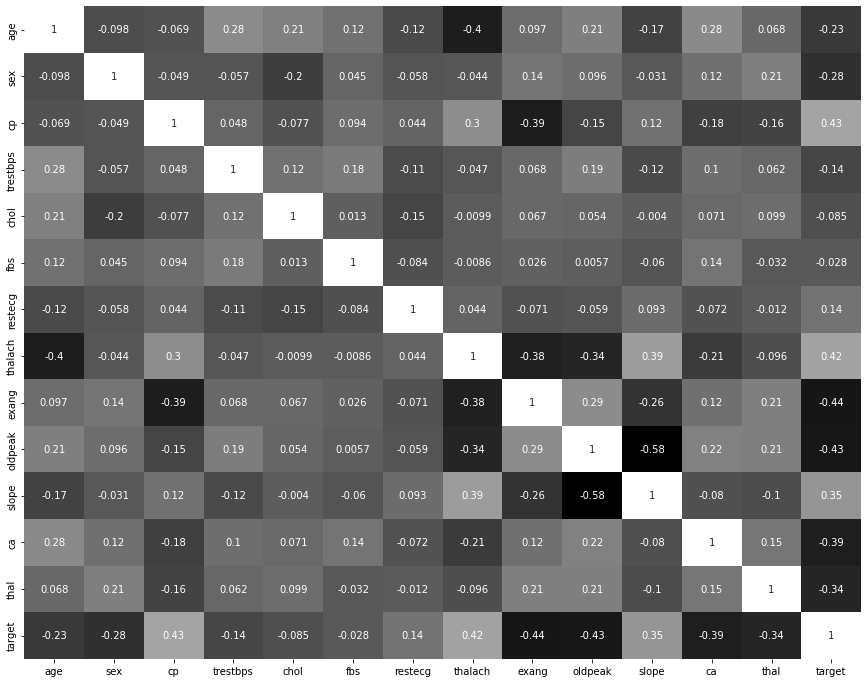

In [9]:
plt.rcParams['figure.figsize'] = (15, 12)
sns.heatmap(dataset.corr(), cmap='gray', annot=True, cbar=False)
plt.show()

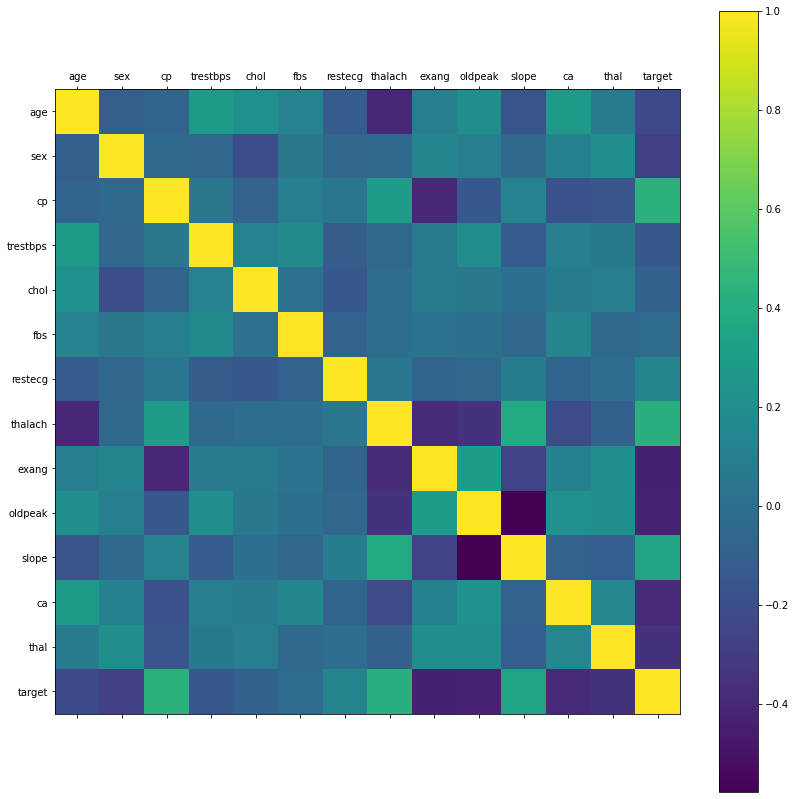

In [10]:
rcParams['figure.figsize'] = 20, 14
plt.matshow(dataset.corr())
plt.yticks(np.arange(dataset.shape[1]), dataset.columns)
plt.xticks(np.arange(dataset.shape[1]), dataset.columns)
plt.colorbar()

*It’s easy to see that there is no single feature that has a very high correlation with our target value. Also, some of the features have a negative correlation with the target value and some have positive.*

# Histogram

*The best part about this type of plot is that it just takes a single command to draw the plots and it provides so much information in return. Just use dataset.hist().*

array([[<AxesSubplot:title={'center':'age'}>,
        <AxesSubplot:title={'center':'sex'}>,
        <AxesSubplot:title={'center':'cp'}>,
        <AxesSubplot:title={'center':'trestbps'}>],
       [<AxesSubplot:title={'center':'chol'}>,
        <AxesSubplot:title={'center':'fbs'}>,
        <AxesSubplot:title={'center':'restecg'}>,
        <AxesSubplot:title={'center':'thalach'}>],
       [<AxesSubplot:title={'center':'exang'}>,
        <AxesSubplot:title={'center':'oldpeak'}>,
        <AxesSubplot:title={'center':'slope'}>,
        <AxesSubplot:title={'center':'ca'}>],
       [<AxesSubplot:title={'center':'thal'}>,
        <AxesSubplot:title={'center':'target'}>, <AxesSubplot:>,
        <AxesSubplot:>]], dtype=object)

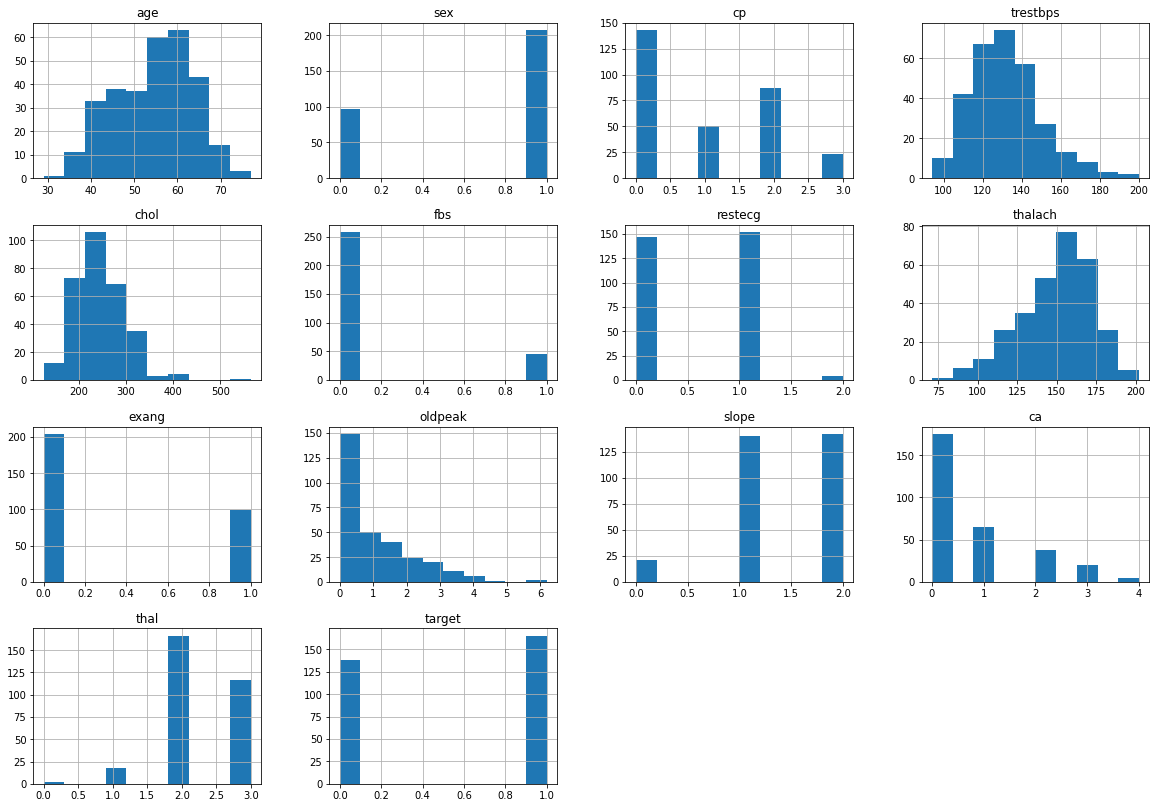

In [11]:
dataset.hist()

*Let’s take a look at the plots. It shows how each feature and label is distributed along different ranges, which further confirms the need for scaling. Next, wherever you see discrete bars, it basically means that each of these is actually a categorical variable. We will need to handle these categorical variables before applying Machine Learning. Our target labels have two classes, 0 for no disease and 1 for disease.*

# Bar Plot for Target Class

*It’s really essential that the dataset we are working on should be approximately balanced. An extremely imbalanced dataset can render the whole model training useless and thus, will be of no use. Let’s understand it with an example.*

Text(0.5, 1.0, 'Count of each Target Class')

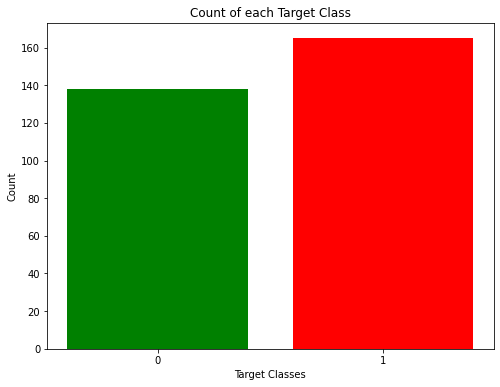

In [12]:
rcParams['figure.figsize'] = 8,6
plt.bar(dataset['target'].unique(), dataset['target'].value_counts(), color = ['red', 'green'])
plt.xticks([0, 1])
plt.xlabel('Target Classes')
plt.ylabel('Count')
plt.title('Count of each Target Class')

*For x-axis I used the unique() values from the target column and then set their name using xticks. For y-axis, I used value_count() to get the values for each class. I colored the bars as green and red.*

In [13]:
dataset.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

# Data Processing

* To work with categorical variables, we should break each categorical column into dummy columns with 1s and 0s.

* Let’s say we have a column Gender, with values 1 for Male and 0 for Female. It needs to be converted into two columns with the value 1 where the column would be true and 0 where it will be false. Take a look at the Gist below.

* To work with categorical variables, we should break each categorical column into dummy columns with 1s and 0s.

* Let’s say we have a column Gender, with values 1 for Male and 0 for Female. It needs to be converted into two columns with the value 1 where the column would be true and 0 where it will be false. Take a look at the Gist below.

# Checking null values

In [14]:
dataset.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

*There is no Null Values*

In [15]:
dataset = pd.get_dummies(dataset, columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'])
standardScaler = StandardScaler()
columns_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
dataset[columns_to_scale] = standardScaler.fit_transform(dataset[columns_to_scale])

In [16]:
dataset.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_0,sex_1,cp_0,cp_1,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,0.952197,0.763956,-0.256334,0.015443,1.087338,1,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
1,-1.915313,-0.092738,0.072199,1.633471,2.122573,1,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
2,-1.474158,-0.092738,-0.816773,0.977514,0.310912,1,1,0,0,1,...,1,1,0,0,0,0,0,0,1,0
3,0.180175,-0.663867,-0.198357,1.239897,-0.206705,1,0,1,0,1,...,1,1,0,0,0,0,0,0,1,0
4,0.290464,-0.663867,2.082050,0.583939,-0.379244,1,1,0,1,0,...,1,1,0,0,0,0,0,0,1,0


# Splitting Data into Train Test

In [17]:
y = dataset['target']
X = dataset.drop(['target'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle=True)

# Checking Noise in Data using Isolation Forest Algorithm

In [18]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [19]:
# Tune the Isolation Forest Model
#model = IsolationForest(random_state = 47)

#param_grid = {'n_estimators':[1000, 1500],
#              'max_samples': [10],
 #             'contamination': ['auto', 0.0001, 0.0002],
  #            'max_features': [10, 15],
   #           'bootstrap': [True],
    #          'n_jobs': [-1]
     #        }

#grid_search = GridSearchCV(model,
 #                          param_grid,
  #                         scoring='accuracy',
   #                        refit = True,
    #                       cv = 10,
     #                      return_train_score = True
      #                    )

#grid_search.fit(X_train, y_train)

#best_model = grid_search.fit(X_train, y_train)
#print('Optimum parameters', best_model.best_params_)

*Gained output from the Isolation Forest. It takes some time to run. So, saving the values*

bootstrap= True, 
                          contamination= 0.0001, 
                          max_features= 10, 
                          max_samples= 10, 
                          n_estimators= 1000, 
                          n_jobs= -1

In [20]:
# Run the tuned Isolation Frest model
iforest = IsolationForest(bootstrap= True, 
                          contamination= 0.0001, 
                          max_features= 10, 
                          max_samples= 10, 
                          n_estimators= 1000, 
                          n_jobs= -1,
                          random_state=1
                         )

y_pred = iforest.fit_predict(X_train)

In [21]:
y_pred

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [22]:
np.where(y_pred==-1)

(array([177]),)

In [23]:
X_train = X_train.drop([X_train.index[177]])
y_train = y_train.drop([y_train.index[177]])

# Machine Learning

*In this project, I took 4 algorithms and varied their various parameters and compared the final models. I split the dataset into 80% training data and 20% testing data.*

**K Neighbors Classifier**

*This classifier looks for the classes of K nearest neighbors of a given data point and based on the majority class, it assigns a class to this data point. However, the number of neighbors can be varied. I varied them from 1 to 20 neighbors and calculated the test score in each case.*

In [24]:
knn_scores = []
for k in range(1,21):
    knn_classifier = KNeighborsClassifier(n_neighbors = k)
    knn_classifier.fit(X_train, y_train)
    knn_scores.append(knn_classifier.score(X_test, y_test))

*Plot a line graph of the number of neighbors and the test score achieved in each case.*

Text(0.5, 1.0, 'K Neighbors Classifier scores for different K values')

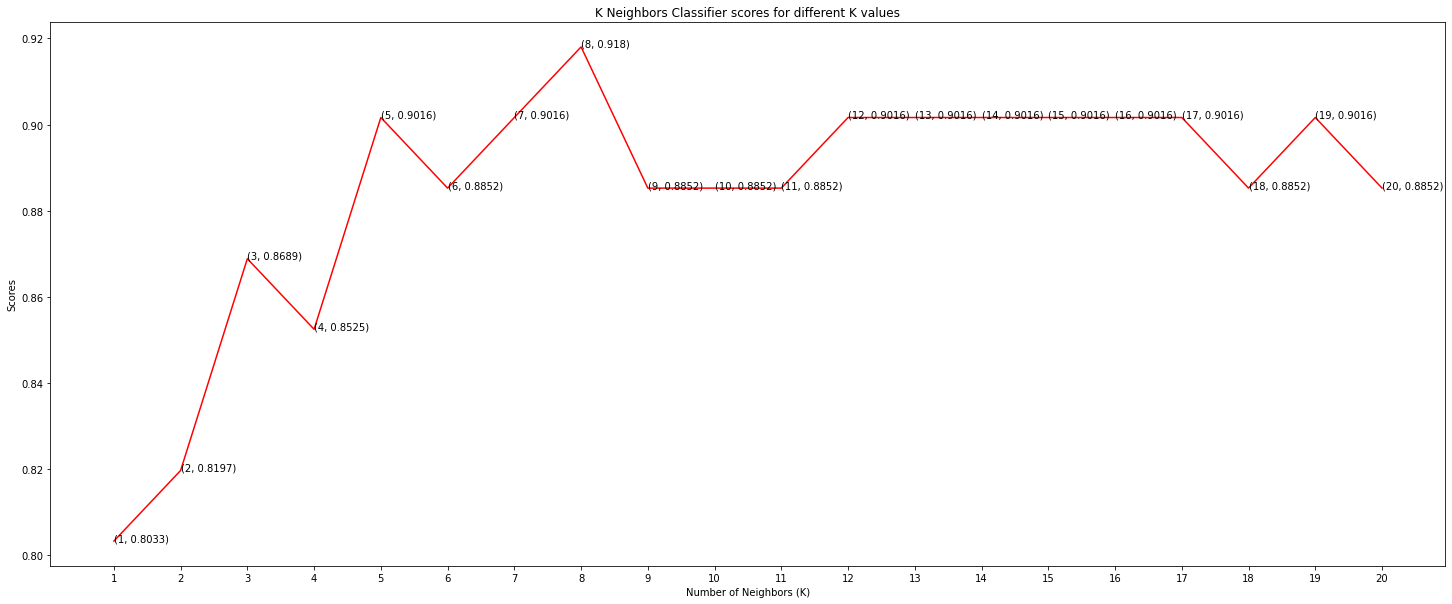

In [25]:
plt.figure(figsize=(25,10))
plt.plot([k for k in range(1, 21)], knn_scores, color = 'red')
for i in range(1,21):
    plt.text(i, knn_scores[i-1], (i, round(knn_scores[i-1],4)))
plt.xticks([i for i in range(1, 21)])
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Scores')
plt.title('K Neighbors Classifier scores for different K values')

As you can see, we achieved the maximum score of 91.8% when the number of neighbors was chosen to be 8.

# Cross Validating Best Model

In [26]:
from sklearn.model_selection import cross_val_score

knn_classifier = KNeighborsClassifier(n_neighbors = 8)

knn_classifier.fit(X_train, y_train)
cross_val_score(knn_classifier, X_train, y_train, cv=5)

array([0.75510204, 0.85416667, 0.8125    , 0.8125    , 0.85416667])

# Gaining all metric value for test

In [27]:
from sklearn.metrics import classification_report

y_pred = knn_classifier.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



# Saving the best model

In [28]:
import pickle

knn_classifier = KNeighborsClassifier(n_neighbors = 8)
knn_classifier.fit(X_train, y_train)

#Save model
filename = 'knn.pkl'
pickle.dump(knn_classifier, open(filename, 'wb'))

In [29]:
#List Hyperparameters that we want to tune.
#leaf_size = list(range(1,50))
#n_neighbors = list(range(1,30))
#p=[1,2]#Convert to dictionary

#hyperparameters = dict(leaf_size=leaf_size, n_neighbors=n_neighbors, p=p)#Create new KNN object

#knn_2 = KNeighborsClassifier()#Use GridSearch

#clf = GridSearchCV(knn_2, hyperparameters, cv=10)#Fit the model
#best_model = clf.fit(X_train, y_train)#Print The value of best Hyperparameters

#print('Best leaf_size:', best_model.best_estimator_.get_params()['leaf_size'])
#print('Best p:', best_model.best_estimator_.get_params()['p'])
#print('Best n_neighbors:', best_model.best_estimator_.get_params()['n_neighbors'])

* Best leaf_size: 1
* Best p: 1
* Best n_neighbors: 11

In [30]:
knn_classifier = KNeighborsClassifier(leaf_size=1, p=1, n_neighbors=11)
knn_classifier.fit(X_train, y_train)

knn_classifier.score(X_test, y_test)

0.8852459016393442

In [31]:
cross_val_score(knn_classifier, X_train, y_train, cv=10)

array([0.8       , 0.83333333, 0.95833333, 0.79166667, 0.83333333,
       0.70833333, 0.875     , 0.875     , 0.91666667, 0.83333333])

In [32]:
y_pred = knn_classifier.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



# Support Vector Classifier

*This classifier aims at forming a hyperplane that can separate the classes as much as possible by adjusting the distance between the data points and the hyperplane. There are several kernels based on which the hyperplane is decided. I tried four kernels namely, linear, poly, rbf, and sigmoid.*

In [33]:
svc_scores = []
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for i in range(len(kernels)):
    svc_classifier = SVC(kernel = kernels[i])
    svc_classifier.fit(X_train, y_train)
    svc_scores.append(svc_classifier.score(X_test, y_test))

*I used the rainbow method to select different colors for each bar and plot a bar graph of the scores achieved by each.*

Text(0.5, 1.0, 'Support Vector Classifier scores for different kernels')

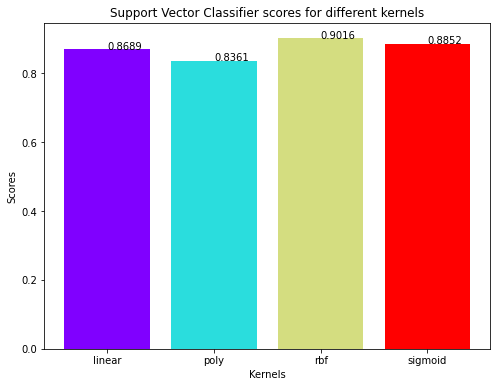

In [34]:
colors = rainbow(np.linspace(0, 1, len(kernels)))
plt.bar(kernels, svc_scores, color = colors)
for i in range(len(kernels)):
    plt.text(i, svc_scores[i], round(svc_scores[i],4))
plt.xlabel('Kernels')
plt.ylabel('Scores')
plt.title('Support Vector Classifier scores for different kernels')

*As can be seen from the plot above, the rbf kernel performed the best for this dataset and achieved a score of 90.16%.*

# Cross Validating Best Model

In [35]:
from sklearn.model_selection import cross_val_score

svc_classifier = SVC(kernel = 'rbf')

svc_classifier.fit(X_train, y_train)
cross_val_score(svc_classifier, X_train, y_train, cv=10)

array([0.84      , 0.875     , 0.91666667, 0.75      , 0.79166667,
       0.66666667, 0.79166667, 0.83333333, 0.75      , 0.83333333])

# Gaining all metric value for test

In [36]:
from sklearn.metrics import classification_report

y_pred = svc_classifier.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



# Decision Tree Classifier

*This classifier creates a decision tree based on which, it assigns the class values to each data point. Here, we can vary the maximum number of features to be considered while creating the model. 'i' range features from 1 to 30 (the total features in the dataset after dummy columns were added).*

In [37]:
dt_scores = []
for i in range(1, len(X.columns) + 1):
    dt_classifier = DecisionTreeClassifier(max_features = i, random_state = 0)
    dt_classifier.fit(X_train, y_train)
    dt_scores.append(dt_classifier.score(X_test, y_test))

*Once we have the scores, we can then plot a line graph and see the effect of the number of features on the model scores.*

Text(0.5, 1.0, 'Decision Tree Classifier scores for different number of maximum features')

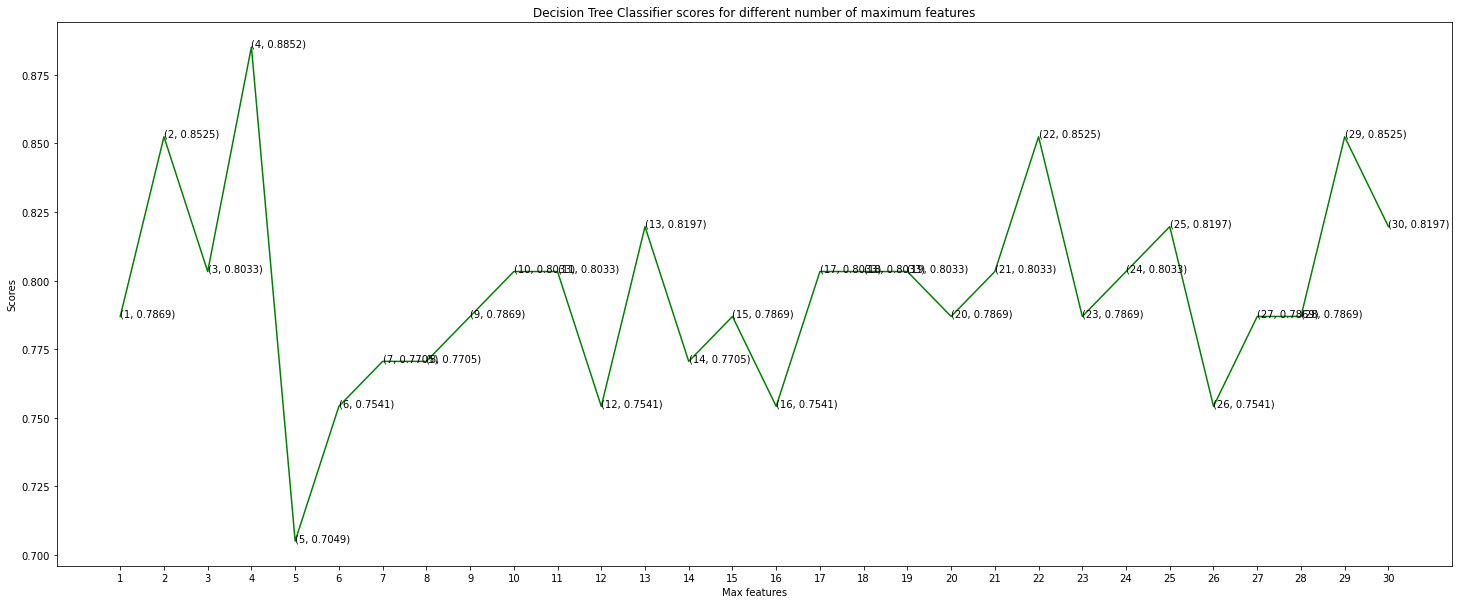

In [38]:
plt.figure(figsize=(25,10))

plt.plot([i for i in range(1, len(X.columns) + 1)], dt_scores, color = 'green')
for i in range(1, len(X.columns) + 1):
    plt.text(i, dt_scores[i-1], (i, round(dt_scores[i-1],4)))
plt.xticks([i for i in range(1, len(X.columns) + 1)])
plt.xlabel('Max features')
plt.ylabel('Scores')
plt.title('Decision Tree Classifier scores for different number of maximum features')

*From the line graph above, we can clearly see that the maximum score is 88.52% and is achieved for maximum features being selected to be 4.*

# Cross Validating Best Model

In [39]:
from sklearn.model_selection import cross_val_score

dt_classifier = DecisionTreeClassifier(max_features = 4, random_state = 0)

dt_classifier.fit(X_train, y_train)
cross_val_score(dt_classifier, X_train, y_train, cv=5)

array([0.81632653, 0.6875    , 0.6875    , 0.75      , 0.66666667])

# Gaining all metric value for test

In [40]:
from sklearn.metrics import classification_report

y_pred = dt_classifier.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88        29
           1       0.90      0.88      0.89        32

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



# Random Forest Classifier

*This classifier takes the concept of decision trees to the next level. It creates a forest of trees where each tree is formed by a random selection of features from the total features. Here, we can vary the number of trees that will be used to predict the class. I calculate test scores over 10, 100, 200, 500 and 1000 trees.*

In [41]:
rf_scores = []
estimators = [10, 100, 200, 500, 1000]
for i in estimators:
    rf_classifier = RandomForestClassifier(n_estimators = i, random_state = 0)
    rf_classifier.fit(X_train, y_train)
    rf_scores.append(rf_classifier.score(X_test, y_test))

*Next, I plot these scores across a bar graph to see which gave the best results. You may notice that I did not directly set the X values as the array [10, 100, 200, 500, 1000]. It will show a continuous plot from 10 to 1000, which would be impossible to decipher. So, to solve this issue, I first used the X values as [1, 2, 3, 4, 5]. Then, I renamed them using xticks.*

Text(0.5, 1.0, 'Random Forest Classifier scores for different number of estimators')

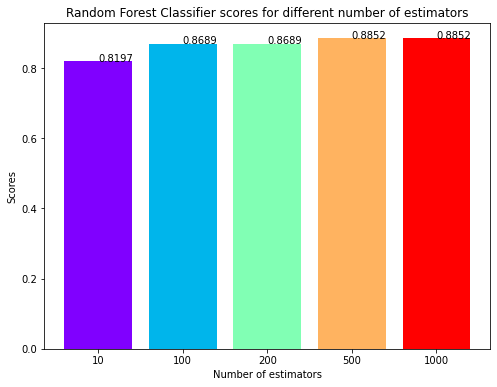

In [42]:
colors = rainbow(np.linspace(0, 1, len(estimators)))
plt.bar([i for i in range(len(estimators))], rf_scores, color = colors, width = 0.8)
for i in range(len(estimators)):
    plt.text(i, rf_scores[i], round(rf_scores[i],4))
plt.xticks(ticks = [i for i in range(len(estimators))], labels = [str(estimator) for estimator in estimators])
plt.xlabel('Number of estimators')
plt.ylabel('Scores')
plt.title('Random Forest Classifier scores for different number of estimators')

*Taking a look at the bar graph, we can see that the maximum score of 86.88% was achieved for both 100, 200,500 and 1000 trees*

# Cross Validating Best Model

In [43]:
from sklearn.model_selection import cross_val_score

rf_classifier = RandomForestClassifier(n_estimators = 100, random_state = 0)

rf_classifier.fit(X_train, y_train)
cross_val_score(rf_classifier, X_train, y_train, cv=10)

array([0.8       , 0.91666667, 0.875     , 0.83333333, 0.875     ,
       0.70833333, 0.79166667, 0.83333333, 0.79166667, 0.83333333])

# Gaining all metric value for test

In [44]:
from sklearn.metrics import classification_report

y_pred = rf_classifier.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86        29
           1       0.85      0.91      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



# Conclusion

*The project involved analysis of the heart disease patient dataset with proper data processing. Then, 4 models were trained and tested with maximum scores as follows:*

1. K Neighbors Classifier: Training Accuracy: 91.8%, Testing Accuracy: 92%
2. Support Vector Classifier: Training Accuracy:90.16%, Testing Accuracy: 90%
3. Decision Tree Classifier: Training Accuracy: 88.52%, Testing Accuracy: 89%
4. Random Forest Classifier: Training Accuracy: 88.52%, Testing Accuracy:87%